In [ ]:
import json

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt



In [ ]:
with open("./model-01/loss_log.json") as f:
    loss_log = json.load(f)

# Training loss is logged at every step.
df = pd.DataFrame({
    "step": loss_log["steps"],
    "train_loss": loss_log["train"],
})

# Validation loss is logged only at steps divisible by 100.
val_steps = [step for step in loss_log["steps"] if step % 100 == 0]
val_df = pd.DataFrame({
    "step": val_steps,
    "val_loss": loss_log["val"],
})

df = df.merge(val_df, on="step", how="left")
df.shape

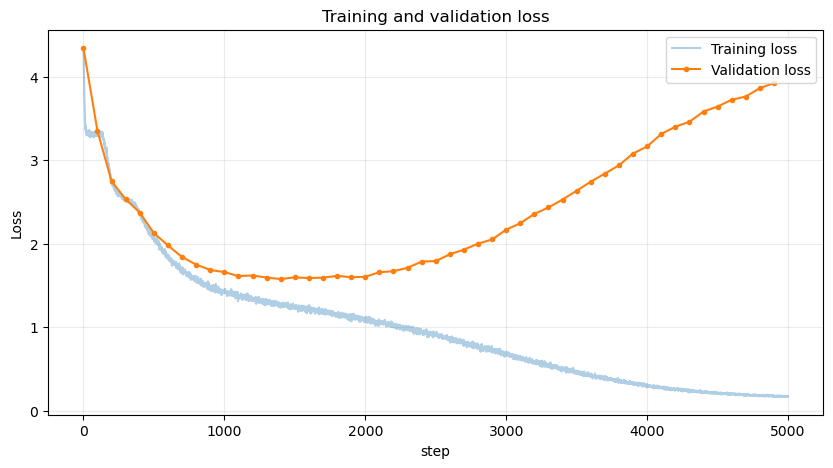

In [8]:
ax = df.plot(
    x="step",
    y="train_loss",
    alpha=0.35,
    figsize=(10, 5),
    label="Training loss",
)
df.dropna(subset=["val_loss"]).plot(
    x="step",
    y="val_loss",
    ax=ax,
    marker="o",
    markersize=3,
    label="Validation loss",
)
ax.set_ylabel("Loss")
ax.set_title("Training and validation loss")
ax.grid(alpha=0.25)
plt.show()